# Classifier Training

Train a classifier (ML) to detect familiar/unfamiliar face viewing based on ERP component statistical features.  

Classifiers to test:
- Support Vector Machine (SVM) 
- K Nearest Neighbors (KNN)
- Logistic Regression (strong baseline)
- Random Forest
- Convolutional Neural Network (CNN) *massive datasets are preferred*
- Recurrent Neural Network (RNN) *massive datasets are preferred*

In [261]:
## Config
n_cv_split = 5  # cross-validation splits/folds
custom_class_weight = {0: 1, 1: 1.75}  # ratio of familiar : unfamiliar weighting

## 1. Load and Preprocess Data

In [189]:
## Imports
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split

### Load Data

Load csv data with extracted features.

In [190]:
## Load data
n_experiment = 3  ### Change to a list with all experiments and concatenation later
data_dir = f'experiment_data/exp{n_experiment}/'
file_name = f'erp_exp{n_experiment}_features.csv'

data = pd.read_csv(data_dir + file_name)

In [191]:
## Data info
print("ERP Feature Data Info:")
print(data.info())
print(data.head())

ERP Feature Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 91 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   condition         79 non-null     object 
 1   Cz_mean           79 non-null     float64
 2   Cz_median         79 non-null     float64
 3   Cz_max            79 non-null     float64
 4   Cz_min            79 non-null     float64
 5   Cz_ptp            79 non-null     float64
 6   Cz_std            79 non-null     float64
 7   Cz_skew           79 non-null     float64
 8   Cz_auc            79 non-null     float64
 9   Cz_kurtosis       79 non-null     float64
 10  Pz_mean           79 non-null     float64
 11  Pz_median         79 non-null     float64
 12  Pz_max            79 non-null     float64
 13  Pz_min            79 non-null     float64
 14  Pz_ptp            79 non-null     float64
 15  Pz_std            79 non-null     float64
 16  Pz_skew           79 no

### Preprocessing

1. Re-label class labels (0 for familiar, 1 for unfamiliar) and remove 'move' types 
2. Remove outliers (if any)
3. Scale/normalize (StandardScaler)

In [192]:
## Relablel class labels
# Filter out 'Mov' rows first
data = data[data['condition'].isin(['Fam', 'Unf'])]

# Map string labels to binary (0 - familiar, 1 - unfamiliar)
data['condition'] = data['condition'].map({'Fam': 0, 'Unf': 1})
data = data.rename(columns={'condition': 'IS_UNFAMILIAR'})

print("Relabeled ERP Feature Data Info:")
print(data.head())

Relabeled ERP Feature Data Info:
   IS_UNFAMILIAR    Cz_mean  Cz_median     Cz_max     Cz_min     Cz_ptp  \
3              0 -17.010920 -15.725029 -10.681747 -30.338906  19.657159   
4              1  -0.872291  -2.654858  15.171267 -13.495091  28.666359   
5              0   2.773336   3.275493   6.743870  -1.920382   8.664253   
6              1   9.436099  15.041365  20.332314 -16.588980  36.921294   
7              0  -2.701357  -0.572594  22.601012 -26.880467  49.481479   

      Cz_std   Cz_skew    Cz_auc  Cz_kurtosis  ...  N250avg_kurtosis  \
3   5.075956 -1.152427 -1.671854     3.783341  ...          3.282067   
4   7.961080  0.227932 -0.093854     1.960919  ...          2.110011   
5   2.419836 -0.275789  0.278148     1.999819  ...          2.817995   
6  11.727383 -1.091657  0.987352     2.729342  ...          2.335161   
7  15.604066 -0.022512 -0.288961     1.948767  ...          2.313673   

   P300avg_mean  P300avg_median  P300avg_max  P300avg_min  P300avg_ptp  \
3    -17.

In [193]:
## Prepare data
X = data.drop(columns=['IS_UNFAMILIAR'])
y = data['IS_UNFAMILIAR']

# Currently using all data for training due to limited dataset size
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0, random_state=42)
X_train, y_train = X, y 

In [194]:
## Scale features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

print("Scaled ERP Feature Data Info:")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

Scaled ERP Feature Data Info:
    Cz_mean  Cz_median    Cz_max    Cz_min    Cz_ptp    Cz_std   Cz_skew  \
0 -1.191459  -1.069167 -1.545980 -1.137087 -0.128944 -0.309727 -1.598498   
1  0.024926  -0.107424  0.513955 -0.072693  0.695820  0.505873  0.612989   
2  0.299700   0.328949 -0.157529  0.658735 -1.135310 -1.060590 -0.194026   
3  0.801879   1.194718  0.925181 -0.268202  1.451534  1.570574 -1.501137   
4 -0.112933   0.045795  1.105948 -0.918541  2.601380  2.666479  0.211751   

     Cz_auc  Cz_kurtosis   Pz_mean  ...  N250avg_kurtosis  P300avg_mean  \
0 -1.172904     1.237352 -1.191459  ...          1.355927     -1.191459   
1  0.016396    -0.533741  0.024926  ...         -0.867825      0.024926   
2  0.296765    -0.495937  0.299700  ...          0.475440      0.299700   
3  0.831275     0.213039  0.801879  ...         -0.440647      0.801879   
4 -0.130651    -0.545551 -0.112933  ...         -0.481414     -0.112933   

   P300avg_median  P300avg_max  P300avg_min  P300avg_ptp  P300

## 2. SVM Classifier

Build an SVM classifier, evaluate training accuracy, and identify contribution from different features. 

Look for the channels with the greatest impact, and observe the effect for removing certain channels.

In [152]:
## Imports
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay, permutation_importance
import seaborn as sns

### Train Initial SVM

In [262]:
## Train and evaluate SVM
# Params:
# kernel: rbf (default), linear, poly, sigmoid
# C (regularization parameter): default=1.0
# gamma (kernel coefficient): scale (default), auto, or float value ()
# class_weight (weight of classes): None (default), 'balanced', or dict

svm = SVC(kernel='rbf', C=1, gamma='scale', random_state=42, class_weight=custom_class_weight)
svm.fit(X_train_scaled, y_train)

# Evaluate
train_accuracy = svm.score(X_train_scaled, y_train)
# test_accuracy = svm.score(X_test_scaled, y_test)

y_train_pred_temp = svm.predict(X_train_scaled)
train_recall = recall_score(y_train, y_train_pred_temp)

print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Training Recall: {train_recall:.3f}")
# print(f"Test Accuracy: {test_accuracy:.3f}")

# Cross-validation for more robust estimate (folds data n times)
cv_accuracy = cross_val_score(svm, X_train_scaled, y_train, cv=n_cv_split, scoring='accuracy')
cv_recall = cross_val_score(svm, X_train_scaled, y_train, cv=n_cv_split, scoring='recall')
print(f"CV Accuracy: {cv_accuracy.mean():.3f} (+/- {cv_accuracy.std() * 2:.3f})")
print(f"CV Recall: {cv_recall.mean():.3f} (+/- {cv_recall.std() * 2:.3f})")

Training Accuracy: 0.803
Training Recall: 1.000
CV Accuracy: 0.592 (+/- 0.061)
CV Recall: 0.900 (+/- 0.245)


Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.61      0.75        38
           1       0.72      1.00      0.84        38

    accuracy                           0.80        76
   macro avg       0.86      0.80      0.79        76
weighted avg       0.86      0.80      0.79        76

Training Confusion Matrix:


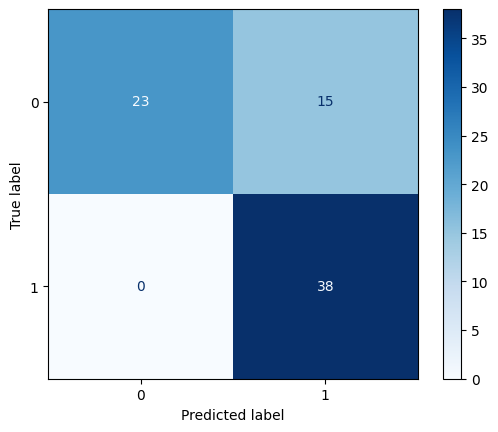

In [231]:
## Classification Report & Confusion Matrix
y_train_pred = svm.predict(X_train_scaled)
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred))

print("Training Confusion Matrix:")
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

### Plot Decision Boundary for Different Kernels

Use PCA to represent the data in the two major components. 

Then, train SVC model and plot decision boundaries. Identify which kernel has the best performance.

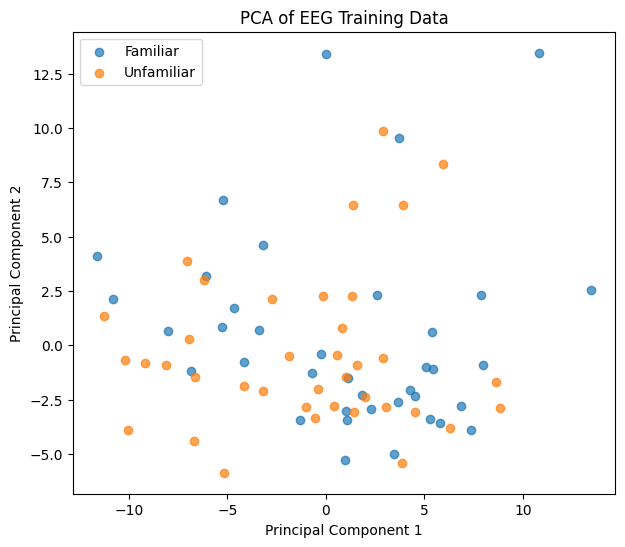

In [132]:
## PCA to 2D for visualization 
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Plot PCA results
plt.figure(figsize=(7, 6))
class_labels = ['Familiar', 'Unfamiliar']
for label in np.unique(y_train):
    plt.scatter(X_train_pca[y_train == label, 0], X_train_pca[y_train == label, 1], label=class_labels[label], alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of EEG Training Data')
plt.legend()
plt.show()

In [133]:
## Function to plot decision boundaries
def plot_training_data_with_decision_boundary(
    kernel, ax=None, long_title=True, support_vectors=True
):
    # Train the SVC
    clf = SVC(kernel=kernel, gamma=2, class_weight=custom_class_weight).fit(X_train_pca, y_train)

    # Settings for plotting
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3))
    x_min, x_max, y_min, y_max = -10, 10, -5, 5
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max))

    # Plot decision boundary and margins
    common_params = {"estimator": clf, "X": X_train_pca, "ax": ax}
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.3,
    )
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        colors=["k", "k", "k"],
        linestyles=["--", "-", "--"],
    )

    if support_vectors:
        # Plot bigger circles around samples that serve as support vectors
        ax.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=150,
            facecolors="none",
            edgecolors="k",
        )

    # Plot samples by color and add legend
    scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=30, edgecolors="k")
    ax.legend(*scatter.legend_elements(), loc="upper right", title="IS_UNFAMILIAR")
    if long_title:
        ax.set_title(f" Decision boundaries of {kernel} kernel in SVC")
    else:
        ax.set_title(kernel)

    if ax is None:
        plt.show()
        
    # Classifier accuracy info
    y_train_pred = clf.predict(X_train_pca)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    print(f"{kernel} Kernel Training Accuracy: {train_accuracy:.3f}")
    print(f"{kernel} Kernel Training Recall: {train_recall:.3f}")
    # Number of correct predictions
    correct_predictions = (y_train == y_train_pred).sum()
    print(f"Number of correct predictions: {correct_predictions} out of {len(y_train)}")

linear Kernel Training Accuracy: 0.500
linear Kernel Training Recall: 1.000
Number of correct predictions: 38 out of 76


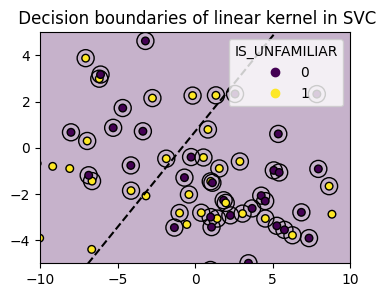

In [134]:
plot_training_data_with_decision_boundary("linear")

poly Kernel Training Accuracy: 0.553
poly Kernel Training Recall: 0.974
Number of correct predictions: 42 out of 76


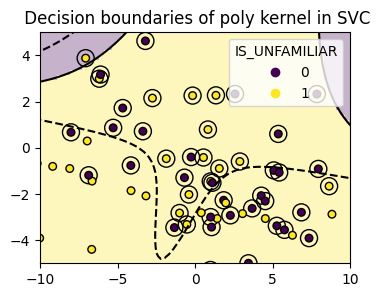

In [135]:
plot_training_data_with_decision_boundary("poly")

rbf Kernel Training Accuracy: 0.921
rbf Kernel Training Recall: 1.000
Number of correct predictions: 70 out of 76


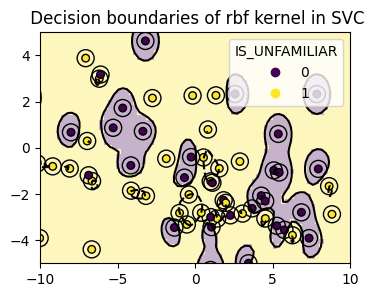

In [136]:
plot_training_data_with_decision_boundary("rbf")

sigmoid Kernel Training Accuracy: 0.395
sigmoid Kernel Training Recall: 0.605
Number of correct predictions: 30 out of 76


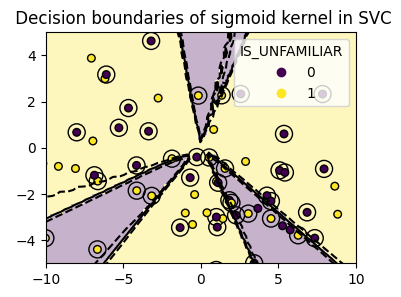

In [137]:
plot_training_data_with_decision_boundary("sigmoid")

Based on these results, rbf is most well-suited for the decision in this task. Although, it could be overfitting.

### Evaluate Feature Importance

In [235]:
## Feature importance analysis
# Calculate permutation importance
perm = permutation_importance(svm, X_train_scaled, y_train, n_repeats=30, random_state=4, scoring='accuracy')
df = pd.DataFrame({'feature': X_train.columns, 'importance': perm.importances_mean})
df['channel'] = df['feature'].str.split('_').str[0]
df['stat'] = df['feature'].str.split('_').str[1]

# Top features with 1-based ranks as the index (no duplicate numbering)
num_features = 20
topN = df.sort_values('importance', ascending=False).head(num_features).reset_index(drop=True)
topN.index = np.arange(1, len(topN) + 1)
topN.index.name = ''
print(f"Top {num_features} Features:")
print(topN[['feature', 'importance']])

# Channel importance
print("\nChannel Importance:")
print(df.groupby('channel')['importance'].sum().sort_values(ascending=False))

# Statistical feature importance
print("\nStatistical Feature Importance:")
print(df.groupby('stat')['importance'].sum().sort_values(ascending=False))

Top 20 Features:
             feature  importance
                                
1        O2_kurtosis    0.037281
2             Cz_std    0.028947
3             P8_std    0.028947
4        P300avg_std    0.028947
5             Pz_std    0.028947
6            O2_skew    0.028947
7        T7_kurtosis    0.028509
8   N250avg_kurtosis    0.028509
9        O1_kurtosis    0.028509
10            Pz_ptp    0.027632
11            P8_ptp    0.027632
12            Cz_ptp    0.027632
13       P300avg_ptp    0.027632
14       P7_kurtosis    0.027193
15         T8_median    0.025877
16           T8_mean    0.020614
17            T8_auc    0.020614
18      P300avg_skew    0.020175
19           Cz_skew    0.020175
20           P8_skew    0.020175

Channel Importance:
channel
P7         0.117544
O2         0.111404
O1         0.108772
N250avg    0.108772
T7         0.108772
T8         0.097807
Cz         0.097807
P300avg    0.097807
Pz         0.097807
P8         0.097807
Name: importance, dtype: flo

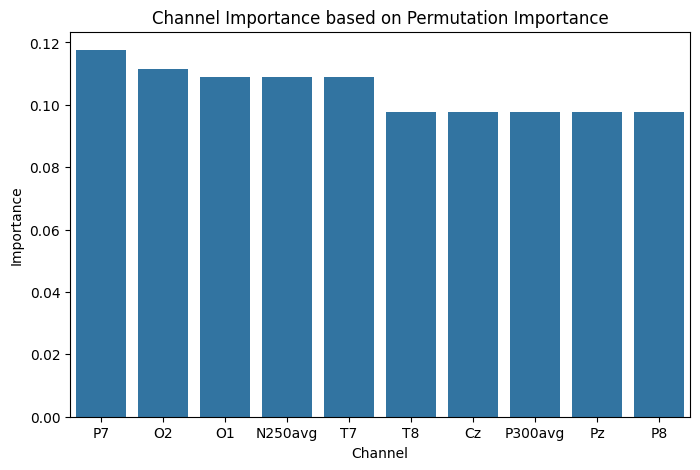

In [233]:
## Plot channel importances
channel_importance = df.groupby('channel')['importance'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=channel_importance.index, y=channel_importance.values)
plt.title('Channel Importance based on Permutation Importance')
plt.xlabel('Channel')
plt.ylabel('Importance')
plt.show()

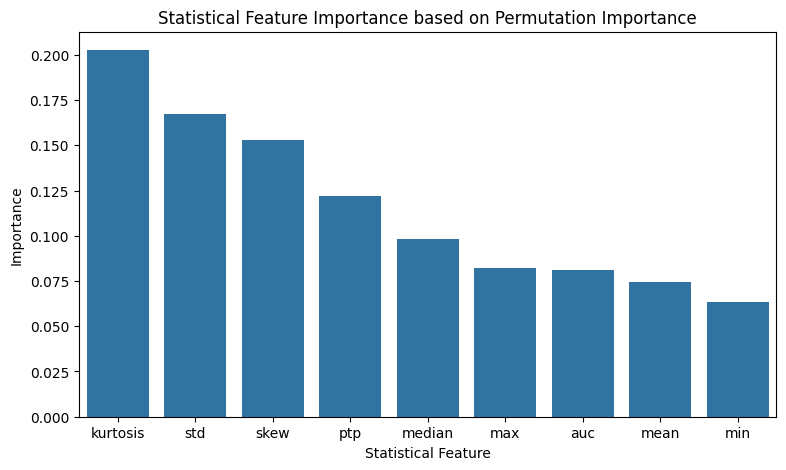

In [234]:
## Plot statistical feature importances
stat_importance = df.groupby('stat')['importance'].sum().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(x=stat_importance.index, y=stat_importance.values)
plt.title('Statistical Feature Importance based on Permutation Importance')
plt.xlabel('Statistical Feature')
plt.ylabel('Importance')
plt.show()

### Re-train WITHOUT poor channels

In [54]:
## Channels to remove from dataset
channels_to_remove = ['O2']

In [55]:
## Remove channel features from dataset
X_train_reduced = X_train.drop(columns=[col for col in X_train.columns if any(col.startswith(f'{ch}_') for ch in channels_to_remove)])
print(f"Reduced feature set shape (removed {channels_to_remove} features): {X_train_reduced.shape}")

Reduced feature set shape (removed ['O2'] features): (76, 54)


In [56]:
## Re-scale reduced dataset
scaler_reduced = StandardScaler()
X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced)
print("Scaled Reduced ERP Feature Data Info:")
print(pd.DataFrame(X_train_reduced_scaled, columns=X_train_reduced.columns).head())

Scaled Reduced ERP Feature Data Info:
    Cz_mean  Cz_median    Cz_max    Cz_min    Cz_ptp    Cz_std   Cz_skew  \
0 -1.191459  -1.069167 -1.545980 -1.137087 -0.128944 -0.309727 -1.598498   
1  0.024926  -0.107424  0.513955 -0.072693  0.695820  0.505873  0.612989   
2  0.299700   0.328949 -0.157529  0.658735 -1.135310 -1.060590 -0.194026   
3  0.801879   1.194718  0.925181 -0.268202  1.451534  1.570574 -1.501137   
4 -0.112933   0.045795  1.105948 -0.918541  2.601380  2.666479  0.211751   

     Cz_auc  Cz_kurtosis   T8_mean  ...  N250avg_kurtosis  P300avg_mean  \
0 -1.172904     1.237352  2.704324  ...          1.355927     -1.191459   
1  0.016396    -0.533741 -1.603754  ...         -0.867825      0.024926   
2  0.296765    -0.495937 -0.986626  ...          0.475440      0.299700   
3  0.831275     0.213039 -0.595902  ...         -0.440647      0.801879   
4 -0.130651    -0.545551 -1.605929  ...         -0.481414     -0.112933   

   P300avg_median  P300avg_max  P300avg_min  P300avg_p

In [ ]:
## Train and evaluate SVM
# Params:
# kernel: rbf (default), linear, poly, sigmoid
# C (regularization parameter): default=1.0

svm_reduced = SVC(kernel='rbf', C=1, random_state=42, class_weight=custom_class_weight)
svm_reduced.fit(X_train_reduced_scaled, y_train)

# Evaluate
train_accuracy = svm_reduced.score(X_train_reduced_scaled, y_train)
# test_accuracy = svm_reduced.score(X_test_reduced_scaled, y_test)

y_train_pred_temp = svm_reduced.predict(X_train_reduced_scaled)
from sklearn.metrics import recall_score
train_recall = recall_score(y_train, y_train_pred_temp)

print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Training Recall: {train_recall:.3f}")
# print(f"Test Accuracy: {test_accuracy:.3f}")


# Cross-validation for more robust estimate (folds data n_cv_split times)

cv_accuracy = cross_val_score(svm_reduced, X_train_reduced_scaled, y_train, cv=n_cv_split, scoring='accuracy')
cv_recall = cross_val_score(svm_reduced, X_train_reduced_scaled, y_train, cv=n_cv_split, scoring='recall')
print(f"CV Accuracy: {cv_accuracy.mean():.3f} (+/- {cv_accuracy.std() * 2:.3f})")
print(f"CV Recall: {cv_recall.mean():.3f} (+/- {cv_recall.std() * 2:.3f})")

Training Accuracy: 0.842
Training Recall: 0.842
CV Accuracy: 0.539 (+/- 0.190)
CV Recall: 0.568 (+/- 0.498)


Training Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        38
           1       0.84      0.84      0.84        38

    accuracy                           0.84        76
   macro avg       0.84      0.84      0.84        76
weighted avg       0.84      0.84      0.84        76

Training Confusion Matrix:


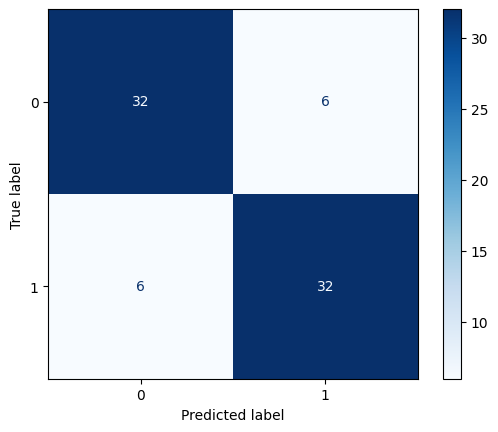

In [58]:
## Classification Report & Confusion Matrix
y_train_pred = svm_reduced.predict(X_train_reduced_scaled)
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred))

print("Training Confusion Matrix:")
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_reduced.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

#### PCA Decision Boundary Check

Re-perform PCA decision boundary check with reduced model

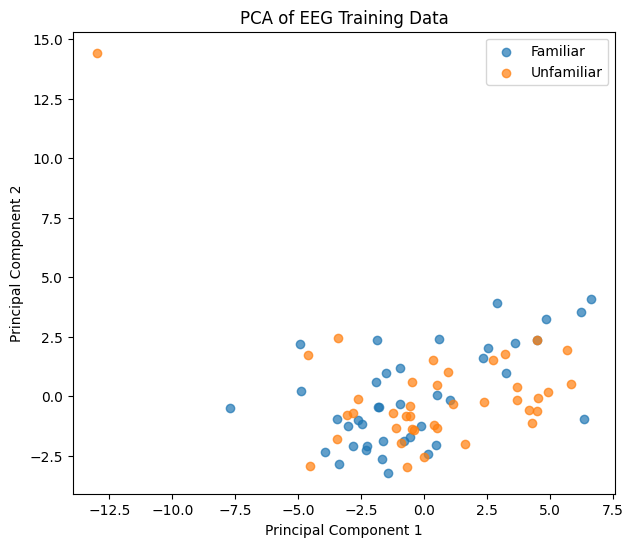

In [187]:
## PCA to 2D for visualization 
pca = PCA(n_components=2)
X_train_reduced_pca = pca.fit_transform(X_train_reduced_scaled)

# Plot PCA results
plt.figure(figsize=(7, 6))
class_labels = ['Familiar', 'Unfamiliar']
for label in np.unique(y_train):
    plt.scatter(X_train_reduced_pca[y_train == label, 0], X_train_reduced_pca[y_train == label, 1], label=class_labels[label], alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of EEG Training Data')
plt.legend()
plt.show()

In [ ]:
## Function to plot decision boundaries
def plot_training_data_with_decision_boundary(
    kernel, ax=None, long_title=True, support_vectors=True
):
    # Train the SVC
    clf = SVC(kernel=kernel, gamma=2, class_weight=custom_class_weight).fit(X_train_reduced_pca, y_train)

    # Settings for plotting
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3))
    x_min, x_max, y_min, y_max = -10, 10, -5, 5
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max))

    # Plot decision boundary and margins
    common_params = {"estimator": clf, "X": X_train_reduced_pca, "ax": ax}
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.3,
    )
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        colors=["k", "k", "k"],
        linestyles=["--", "-", "--"],
    )

    if support_vectors:
        # Plot bigger circles around samples that serve as support vectors
        ax.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=150,
            facecolors="none",
            edgecolors="k",
        )

    # Plot samples by color and add legend
    scatter = ax.scatter(X_train_reduced_pca[:, 0], X_train_reduced_pca[:, 1], c=y_train, s=30, edgecolors="k")
    ax.legend(*scatter.legend_elements(), loc="upper right", title="IS_UNFAMILIAR")
    if long_title:
        ax.set_title(f" Decision boundaries of {kernel} kernel in SVC")
    else:
        ax.set_title(kernel)

    if ax is None:
        plt.show()
        
    # Classifier accuracy info
    y_train_pred = clf.predict(X_train_reduced_pca)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    print(f"{kernel} Kernel Training Accuracy: {train_accuracy:.3f}")
    print(f"{kernel} Kernel Training Recall: {train_recall:.3f}")
    # Number of correct predictions
    correct_predictions = (y_train == y_train_pred).sum()
    print(f"Number of correct predictions: {correct_predictions} out of {len(y_train)}")

linear Kernel Training Accuracy: 0.570
Number of correct predictions: 45 out of 79


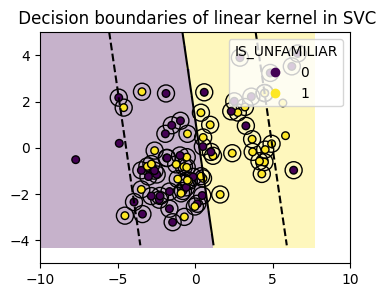

In [183]:
plot_training_data_with_decision_boundary("linear")

poly Kernel Training Accuracy: 0.620
Number of correct predictions: 49 out of 79


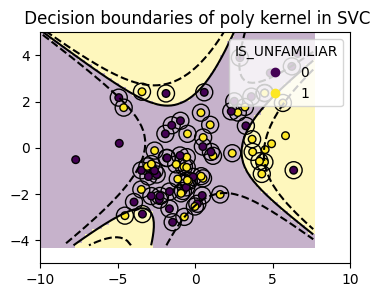

In [184]:
plot_training_data_with_decision_boundary("poly")

rbf Kernel Training Accuracy: 0.886
Number of correct predictions: 70 out of 79


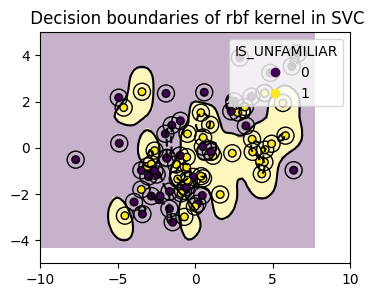

In [185]:
plot_training_data_with_decision_boundary("rbf")

sigmoid Kernel Training Accuracy: 0.582
Number of correct predictions: 46 out of 79


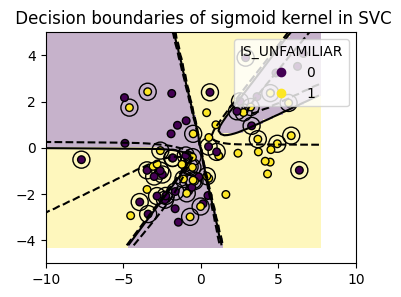

In [186]:
plot_training_data_with_decision_boundary("sigmoid")

Sigmoid performed better than regular, but otherwise the results were very similar for the components. This makes sense, since the major components would not have heavily included features with low contribution.

### Re-train with ONLY averaged features (N250/P300)

In [138]:
## Channels to keep in dataset
channels_to_keep = ['P300avg', 'N250avg']

## Remove channel features from dataset
X_train_reduced = X_train.drop(columns=[col for col in X_train.columns if not any(col.startswith(f'{ch}_') for ch in channels_to_keep)])
print(f"Reduced feature set shape (kept {channels_to_keep} features): {X_train_reduced.shape}")

## Re-scale reduced dataset
scaler_reduced = StandardScaler()
X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced)
print("Scaled Reduced ERP Feature Data Info:")
print(pd.DataFrame(X_train_reduced_scaled, columns=X_train_reduced.columns).head())

Reduced feature set shape (kept ['P300avg', 'N250avg'] features): (76, 18)
Scaled Reduced ERP Feature Data Info:
   N250avg_mean  N250avg_median  N250avg_max  N250avg_min  N250avg_ptp  \
0     -0.156879       -0.180172    -0.348044     0.222117    -0.676726   
1     -0.014589        0.150311    -0.017523    -0.493760     0.501806   
2     -0.969884       -0.942334    -1.174626    -0.644804    -0.804048   
3     -1.728343       -1.810529    -0.774586    -2.158131     1.308874   
4     -1.404152       -1.582950    -0.505204    -1.454308     0.903264   

   N250avg_std  N250avg_skew  N250avg_auc  N250avg_kurtosis  P300avg_mean  \
0    -0.724378      1.228356    -0.155007          1.355927     -1.191459   
1     0.499405     -0.730039    -0.001621         -0.867825      0.024926   
2    -0.831460     -0.289749    -0.958620          0.475440      0.299700   
3     1.558657      1.281320    -1.728890         -0.440647      0.801879   
4     0.877341      1.562093    -1.423675         -0.4814

Training Accuracy: 0.724
Training Recall: 1.000
CV Accuracy: 0.525 (+/- 0.167)
CV Recall: 0.821 (+/- 0.373)
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.45      0.62        38
           1       0.64      1.00      0.78        38

    accuracy                           0.72        76
   macro avg       0.82      0.72      0.70        76
weighted avg       0.82      0.72      0.70        76

Training Confusion Matrix:


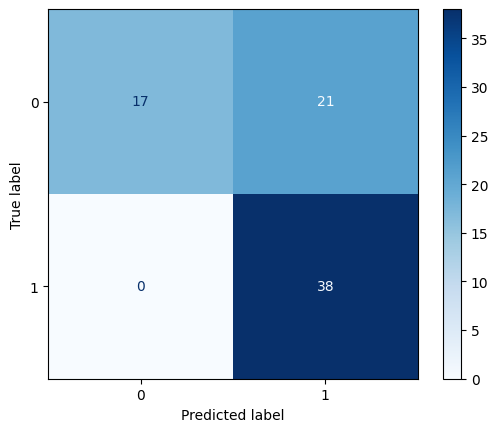

In [139]:
## Train and evaluate SVM
# Params:
# kernel: rbf (default), linear, poly, sigmoid
# C (regularization parameter): default=1.0

svm_reduced = SVC(kernel='rbf', C=1, random_state=42, class_weight=custom_class_weight)
svm_reduced.fit(X_train_reduced_scaled, y_train)

# Evaluate
train_accuracy = svm_reduced.score(X_train_reduced_scaled, y_train)
# test_accuracy = svm_reduced.score(X_test_reduced_scaled, y_test)

y_train_pred_temp = svm_reduced.predict(X_train_reduced_scaled)
from sklearn.metrics import recall_score
train_recall = recall_score(y_train, y_train_pred_temp)

print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Training Recall: {train_recall:.3f}")
# print(f"Test Accuracy: {test_accuracy:.3f}")


# Cross-validation for more robust estimate (folds data n_cv_split times)

cv_accuracy = cross_val_score(svm_reduced, X_train_reduced_scaled, y_train, cv=n_cv_split, scoring='accuracy')
cv_recall = cross_val_score(svm_reduced, X_train_reduced_scaled, y_train, cv=n_cv_split, scoring='recall')
print(f"CV Accuracy: {cv_accuracy.mean():.3f} (+/- {cv_accuracy.std() * 2:.3f})")
print(f"CV Recall: {cv_recall.mean():.3f} (+/- {cv_recall.std() * 2:.3f})")

## Classification Report & Confusion Matrix
y_train_pred = svm_reduced.predict(X_train_reduced_scaled)
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred))

print("Training Confusion Matrix:")
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_reduced.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

## 3. Other Model Exploration

In [267]:
## Imports
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [246]:
## Common evaluation function
def eval_model(name, model, X, y):
    model.fit(X, y)
    train_acc = model.score(X, y)
    train_recall_val = recall_score(y, model.predict(X))
    print(f"{name} Train Acc: {train_acc:.3f}")
    print(f"{name} Train Recall: {train_recall_val:.3f}")
    cv_accuracy = cross_val_score(model, X, y, cv=n_cv_split, scoring='accuracy')
    cv_recall = cross_val_score(model, X, y, cv=n_cv_split, scoring='recall')
    print(f"{name} CV Accuracy: {cv_accuracy.mean():.3f} (+/- {cv_accuracy.std()*2:.3f})")
    print(f"{name} CV Recall: {cv_recall.mean():.3f} (+/- {cv_recall.std()*2:.3f})")
    y_pred = model.predict(X)
    print(classification_report(y, y_pred))

    ConfusionMatrixDisplay(confusion_matrix(y, y_pred)).plot(cmap=plt.cm.Blues)    
    plt.title(f"{name} Confusion Matrix")
    plt.show()

### 3.1 K-Nearest Neighbors (KNN)

KNN Train Acc: 0.750
KNN Train Recall: 0.789
KNN CV Accuracy: 0.578 (+/- 0.324)
KNN CV Recall: 0.725 (+/- 0.600)
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        38
           1       0.73      0.79      0.76        38

    accuracy                           0.75        76
   macro avg       0.75      0.75      0.75        76
weighted avg       0.75      0.75      0.75        76



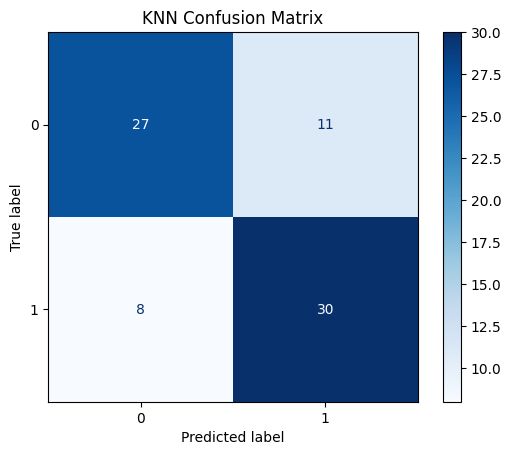

In [265]:
# Train KNN Classifier

# Full dataset
eval_model("KNN", KNeighborsClassifier(n_neighbors=7), X_train_scaled, y_train)
# Reduced dataset
# eval_model("KNN (Reduced)", KNeighborsClassifier(n_neighbors=5), X_train_reduced_scaled, y_train)

### 3.2 Logistic Regression

LogReg Train Acc: 0.697
LogReg Train Recall: 0.921
LogReg CV Accuracy: 0.487 (+/- 0.278)
LogReg CV Recall: 0.643 (+/- 0.394)
              precision    recall  f1-score   support

           0       0.86      0.47      0.61        38
           1       0.64      0.92      0.75        38

    accuracy                           0.70        76
   macro avg       0.75      0.70      0.68        76
weighted avg       0.75      0.70      0.68        76



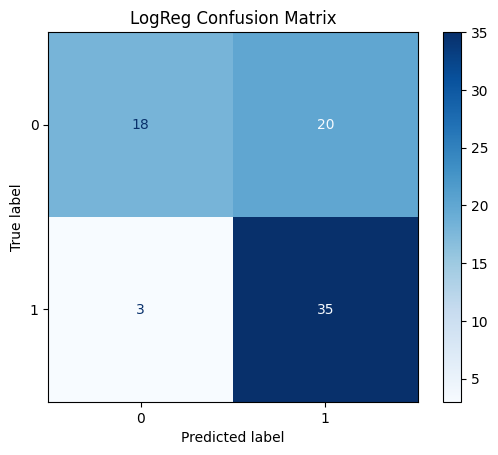

In [266]:
## Train Logistic Regression Classifier

# Full dataset
eval_model("LogReg", LogisticRegression(max_iter=100, solver='liblinear', random_state=42, class_weight=custom_class_weight), X_train_scaled, y_train)
# Reduced dataset
# eval_model("LogReg (Reduced)", LogisticRegression(max_iter=1000, solver='liblinear', random_state=42, class_weight=custom_class_weight), X_train_reduced_scaled, y_train)

### 3.3 Random Forest

RF Train Acc: 1.000
RF Train Recall: 1.000
RF CV Accuracy: 0.580 (+/- 0.386)
RF CV Recall: 0.621 (+/- 0.541)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        38

    accuracy                           1.00        76
   macro avg       1.00      1.00      1.00        76
weighted avg       1.00      1.00      1.00        76



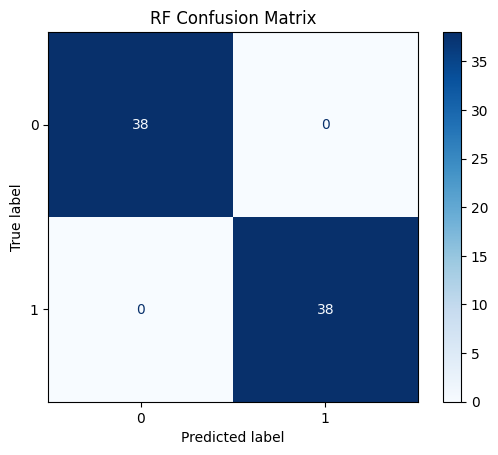

In [257]:
## Train Random Forest Classifier

# Full dataset
eval_model("RF", RandomForestClassifier(n_estimators=25, random_state=42, n_jobs=-1, class_weight=custom_class_weight), X_train_scaled, y_train)
# Reduced dataset
# eval_model("RF (Reduced)", RandomForestClassifier(n_estimators=25, random_state=42, n_jobs=-1, class_weight=custom_class_weight), X_train_reduced_scaled, y_train)

### 3.4 Linear Discriminant Analysis (LDA)

LDA Train Acc: 0.776
LDA Train Recall: 0.816
LDA CV Accuracy: 0.608 (+/- 0.354)
LDA CV Recall: 0.714 (+/- 0.394)
              precision    recall  f1-score   support

           0       0.80      0.74      0.77        38
           1       0.76      0.82      0.78        38

    accuracy                           0.78        76
   macro avg       0.78      0.78      0.78        76
weighted avg       0.78      0.78      0.78        76



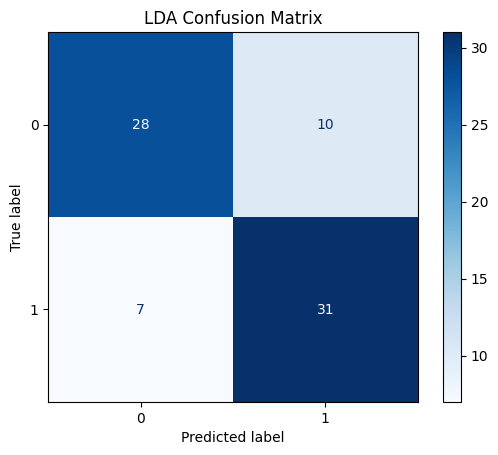

In [275]:
## Train LDA Classifier
# Solver: svd (default), lsqr, eigen
# shrinkage: None (default), 'auto', float value (0,1)

# Full dataset
eval_model("LDA", LinearDiscriminantAnalysis(solver='svd'), X_train_scaled, y_train)
# Reduced dataset
# eval_model("LDA (Reduced)", LinearDiscriminantAnalysis(), X_train_reduced_scaled, y_train)